In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv("/content/OnlineRetail.csv",encoding="latin1")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [7]:
df.shape

(541909, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [11]:
df[df["CustomerID"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


Percentage of Customer ID data

In [12]:
missing_customer_percent = (
    df["CustomerID"].isnull().mean() * 100
)

print(missing_customer_percent)

24.926694334288598


how many customers exist

In [13]:
df["CustomerID"].nunique()

4372

How many orders were placed

In [14]:
df["InvoiceNo"].nunique()

25900

How many different products are sold

In [15]:
df["StockCode"].nunique()

4070

Countries which contributes more sales

In [16]:
df["Country"].value_counts()

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


Checking for negative quantities which represent product returns or cancelled

In [17]:
df[df["Quantity"]<0].value_counts()


InvoiceNo  StockCode  Description                         Quantity  InvoiceDate       UnitPrice  CustomerID  Country       
C543611    82483      WOOD 2 DRAWER CABINET WHITE FINISH  -1        2/10/2011 14:38   4.95       17850.0     United Kingdom    4
C538341    22730      ALARM CLOCK BAKELIKE IVORY          -1        12/10/2010 14:03  3.75       15514.0     United Kingdom    3
           22725      ALARM CLOCK BAKELIKE CHOCOLATE      -1        12/10/2010 14:03  3.75       15514.0     United Kingdom    3
           22976      CIRCUS PARADE CHILDRENS EGG CUP     -12       12/10/2010 14:03  1.25       15514.0     United Kingdom    3
C550165    22962      JAM JAR WITH PINK LID               -1        4/14/2011 16:34   0.85       15358.0     United Kingdom    2
                                                                                                                              ..
C551464    22745      POPPY'S PLAYHOUSE BEDROOM           -6        4/28/2011 16:15   2.10       13085.0     United Kingdom    1
           22746      POPPY'S PLAYHOUSE LIVINGROOM        -6        4/28/2011 16:15   2.10       13085.0     United Kingdom    1
           22748      POPPY'S PLAYHOUSE KITCHEN           -6        4/28/2011 16:15   2.10       13085.0     United Kingdom    1
C551465    21714      CITRONELLA CANDLE GARDEN POT        -3        4/28/2011 16:17   1.25       14640.0     United Kingdom    1
C551463    23152      IVORY SWEETHEART WIRE LETTER RACK   -2        4/28/2011 16:13   3.75       13534.0     United Kingdom    1
Name: count, Length: 8872, dtype: int64

In [18]:
(df['Quantity']<0).sum()

np.int64(10624)

Invoice Cancellation rows

In [19]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

Unique Cancellation Invoices

In [20]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]["InvoiceNo"].nunique()

3836

Data Cleaning

In [21]:
df.duplicated().sum()

np.int64(5268)

In [22]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [23]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [24]:
df = df[
    (df["CustomerID"].notnull()) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [25]:
df.shape


(397884, 8)

In [26]:
duplicates = df.duplicated().sum()
print(duplicates)

5192


In [27]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [29]:
#total spent
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [28]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


Exploratory Data Analysis

In [30]:
df["Revenue"].sum()

np.float64(8911407.904)

Top Countries

In [31]:
top_countries=(
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)

)
top_countries.head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


Top Customers

In [38]:
top_customers=(
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)

)
top_customers.head(10)


,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


Most Frequent Customers

In [39]:
customer_orders=(
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)
customer_orders.head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


Best Selling Products

In [40]:
best_products=(
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
best_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


Highest Revenue Products

In [41]:
highest_revenue_products=(
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
highest_revenue_products.head(10)

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


In [44]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["YearMonth"]=(
    df["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

In [45]:
montly_revenue=(
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
montly_revenue.head(10)

,Revenue
YearMonth,
2011-11,1161817.380
2011-10,1039318.790
2011-09,952838.382
2011-05,678594.560
2011-06,661213.690
2011-08,645343.900
2011-07,600091.011
2011-03,595500.760
2010-12,572713.890


In [49]:
customer_summary = (
    df.groupby("CustomerID")
    .agg({
        "Revenue": "sum",
        "InvoiceNo": "nunique",
        "Quantity": "sum"
    })
)
customer_summary.head(10)

,Revenue,InvoiceNo,Quantity
CustomerID,,,
12346.0,77183.60,1,74215
12347.0,4310.00,7,2458
12348.0,1797.24,4,2341
12349.0,1757.55,1,631
12350.0,334.40,1,197
12352.0,2506.04,8,536
12353.0,89.00,1,20
12354.0,1079.40,1,530
12355.0,459.40,1,240


RFM Analysis

In [50]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [51]:
snapshot_date=df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [52]:
rfm=(
    df.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "Revenue": "sum"
    })
)
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [53]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


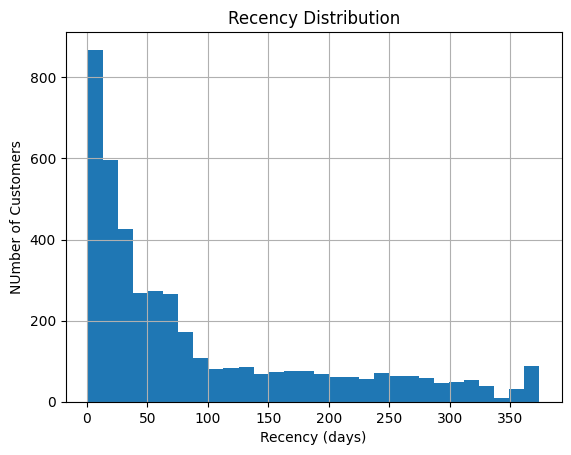

In [54]:
rfm["Recency"].hist(bins=30)
plt.title("Recency Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("NUmber of Customers")
plt.show()

Most customers made purchases within the last 100 days, while a smaller group has been inactive for several months

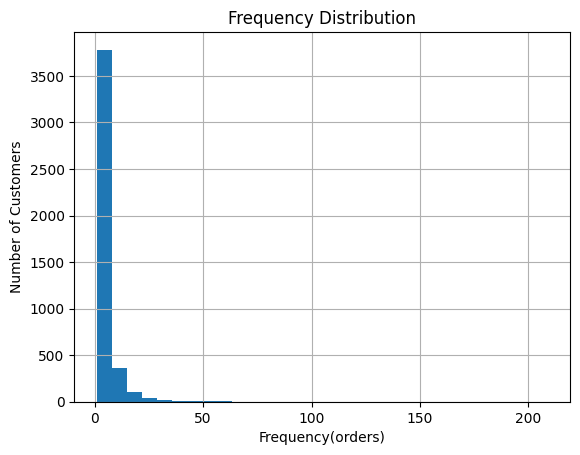

In [55]:
rfm["Frequency"].hist(bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Frequency(orders)")
plt.ylabel("Number of Customers")
plt.show()

The majority of customers place only a few orders, while a small number of highly engaged customers account for a large number of transactions.

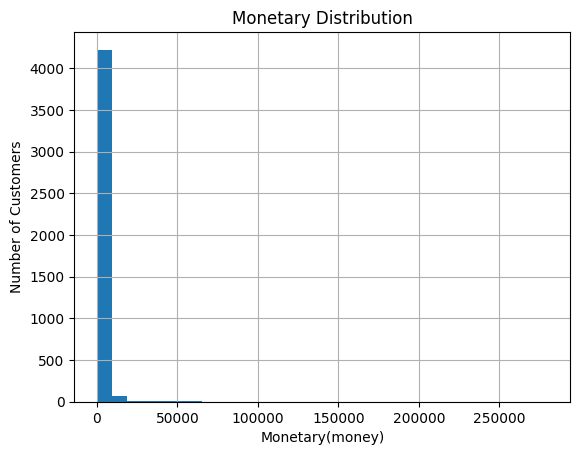

In [56]:
rfm["Monetary"].hist(bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Monetary(money)")
plt.ylabel("Number of Customers")
plt.show()

Most of the customers spend small amounts, while a tiny group of big-spending  customers generates massive revenue for the business.

In [60]:

rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,0.814870,2.013529
std,100.014169,0.267858,0.167083
min,1.000000,0.526589,0.939282
25%,18.000000,0.526589,1.906790
50%,51.000000,0.741276,2.016958
75%,142.000000,1.026672,2.130161
max,374.000000,1.847999,2.605891


Log transformation successfully normalized Frequency and Monetary variables, making them more suitable for clustering and reducing the influence of extreme customer behavior.

<Axes: >

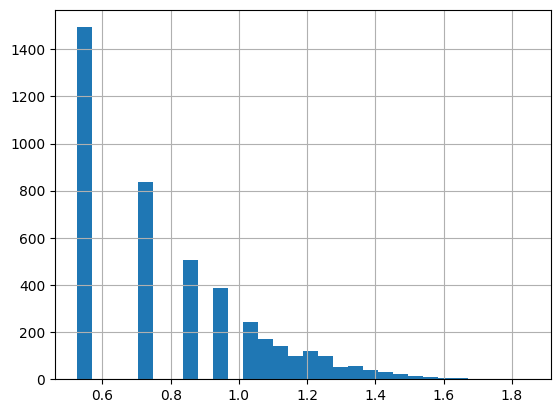

In [61]:
rfm["Frequency"].hist(bins=30)

<Axes: >

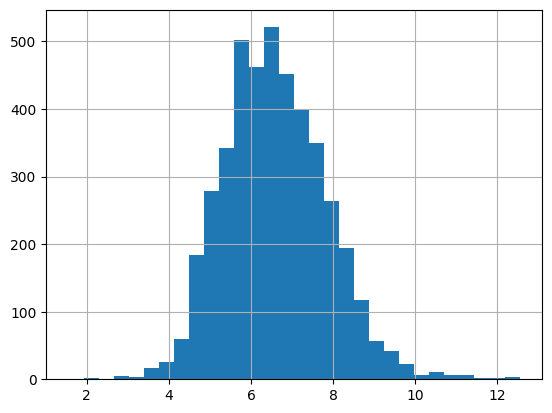

In [59]:
rfm["Monetary"].hist(bins=30)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

In [63]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

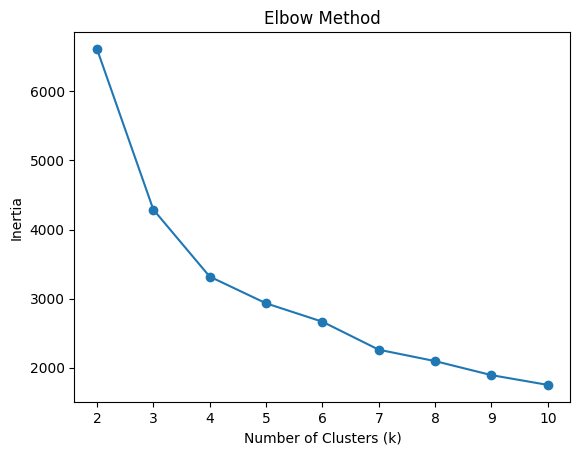

In [64]:
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [66]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [67]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,59.504762,0.582976,1.872520
1,23.632258,1.204473,2.221623
2,264.611299,0.587244,1.881702
3,56.200950,0.870950,2.061863


In [68]:
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [69]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": ["mean", "median"],
    "Frequency": ["mean", "median"],
    "Monetary": ["mean", "median"]
})

cluster_summary

Recency        Frequency            Monetary          
               mean median      mean    median      mean    median
Cluster                                                           
0         59.504762   52.0  0.582976  0.526589  1.872520  1.892987
1         23.632258   13.0  1.204473  1.162283  2.221623  2.209353
2        264.611299  262.0  0.587244  0.526589  1.881702  1.898324
3         56.200950   40.0  0.870950  0.869742  2.061863  2.060039

In [70]:
rfm["Cluster"].value_counts()

,count
Cluster,
3,1473
0,1050
1,930
2,885


<Axes: xlabel='Cluster'>

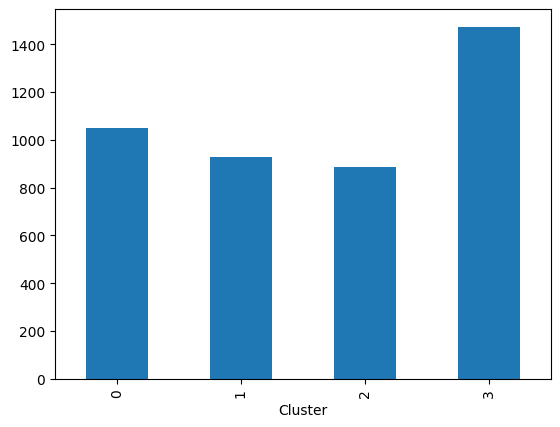

In [71]:
rfm["Cluster"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='Cluster'>

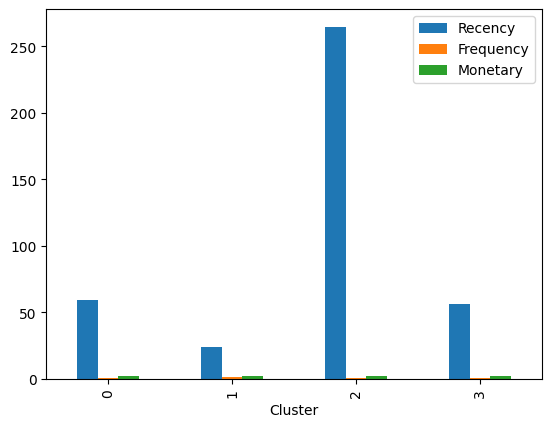

In [72]:
cluster_means = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_means.plot(kind="bar")

In [74]:
segment_map = {
    0: "Potential Loyalists",
    1: "Champions",
    2: "Lost Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)